# Data Manipulation And Balance Checks

This notebook loads the extracted PGN CSV, performs quick data auditing, checks imbalance, creates a few visualizations, and exports Excel-friendly outputs.

Because Excel has a row limit of `1,048,576`, the notebook exports:
- summary sheets for the full dataset
- a raw-data sample sheet small enough for Excel
- a cleaned CSV copy for downstream analysis


In [15]:
import os
import warnings
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [16]:
ROOT = Path('/Users/phamhoanghai/Ureca')
INPUT_PATH = ROOT / 'dataset' / 'output_data.csv'
OUTPUT_DIR = ROOT / 'data_manipulation_output'
PLOT_DIR = ROOT / 'data_manipulation_plots'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

EXCEL_ROW_LIMIT = 1_048_576
RAW_SAMPLE_ROWS = 200_000
RANDOM_STATE = 42

print(INPUT_PATH)
print('Output dir:', OUTPUT_DIR)
print('Plot dir:', PLOT_DIR)


/Users/phamhoanghai/Ureca/dataset/output_data.csv
Output dir: /Users/phamhoanghai/Ureca/data_manipulation_output
Plot dir: /Users/phamhoanghai/Ureca/data_manipulation_plots


In [17]:
def classify_result(result):
    mapping = {
        '1-0': 'white_win',
        '0-1': 'black_win',
        '1/2-1/2': 'draw',
        '0.5-0.5': 'draw',
    }
    return mapping.get(str(result).strip(), 'unknown')


dtype_map = {
    'Event': 'string',
    'Site': 'string',
    'Date': 'string',
    'Round': 'string',
    'White': 'string',
    'Black': 'string',
    'Result': 'string',
    'WhiteTitle': 'string',
    'BlackTitle': 'string',
    'WhiteFideId': 'string',
    'BlackFideId': 'string',
    'UTCDate': 'string',
    'UTCTime': 'string',
    'TimeControl': 'string',
    'Termination': 'string',
    'ECO': 'string',
    'Opening': 'string',
    'Variation': 'string',
    'SubVariation': 'string',
    'Annotator': 'string',
    'GameDate': 'string',
    'GameDateSource': 'string',
    'OpeningCode': 'string',
    'OpeningName': 'string',
    'TimeControlBucket': 'string',
    'GameLengthBucket': 'string',
    'WhiteCastleSide': 'string',
    'BlackCastleSide': 'string',
    'MovesSAN': 'string',
    'MovesUCI': 'string',
    'FinalFEN': 'string',
    'ExtraHeaders': 'string',
}

df = pd.read_csv(INPUT_PATH, dtype=dtype_map, low_memory=False)

drop_metadata_cols = ['WhiteTitle', 'BlackTitle', 'WhiteFideId', 'BlackFideId', 'Variation', 'SubVariation', 'Annotator']
existing_drop_cols = [c for c in drop_metadata_cols if c in df.columns]
if existing_drop_cols:
    df = df.drop(columns=existing_drop_cols)

numeric_cols = [
    'GameID', 'WhiteElo', 'BlackElo', 'WhiteRatingDiff', 'BlackRatingDiff', 'EloDiff', 'AvgElo',
    'NumericResult', 'TimeControlBaseSeconds', 'TimeControlIncrementSeconds',
    'PlyCount', 'MoveCount', 'WhiteCastled', 'BlackCastled',
    'WhiteFirstCastlePly', 'BlackFirstCastlePly',
    'WhiteEarlyQueenMove', 'BlackEarlyQueenMove', 'FirstCapturePly', 'FirstCheckPly',
    'OpeningCaptureCount12Ply', 'OpeningCheckCount12Ply', 'OpeningPieceMoveCount12Ply', 'OpeningPawnMoveCount12Ply',
    'WhitePawnMoves', 'BlackPawnMoves', 'WhiteKnightMoves', 'BlackKnightMoves',
    'WhiteBishopMoves', 'BlackBishopMoves', 'WhiteRookMoves', 'BlackRookMoves',
    'WhiteQueenMoves', 'BlackQueenMoves', 'WhiteKingMoves', 'BlackKingMoves',
    'TotalCaptures', 'TotalChecks', 'TotalPromotions', 'EnPassantCount',
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['WhiteFirstCastlePly', 'BlackFirstCastlePly']:
    if col in df.columns:
        df[col] = df[col].astype('string').replace({'<NA>': 'none', 'nan': 'none'}).fillna('none')

rows_before_dropna = len(df)
df = df.dropna().reset_index(drop=True)
rows_after_dropna = len(df)

df['result_class'] = df['Result'].map(classify_result)
df['is_draw'] = (df['result_class'] == 'draw').astype(int)
df['is_white_win'] = (df['result_class'] == 'white_win').astype(int)
df['is_black_win'] = (df['result_class'] == 'black_win').astype(int)
df['event_group'] = df['Event'].fillna('Unknown').str.lower().str.extract(r'rated\s+([a-z]+)', expand=False).fillna('unknown')

print('Shape:', df.shape)
print('Dropped rows with NaN:', rows_before_dropna - rows_after_dropna)
print(df.dtypes.head(20))
df.head(3)


Shape: (984331, 70)
Dropped rows with NaN: 126971
GameID               int64
Event               string
Site                string
Date                string
Round               string
White               string
Black               string
Result              string
WhiteElo           float64
BlackElo           float64
WhiteRatingDiff    float64
BlackRatingDiff    float64
UTCDate             string
UTCTime             string
TimeControl         string
Termination         string
ECO                 string
Opening             string
EloDiff            float64
AvgElo             float64
dtype: object


,GameID,Event,Site,Date,Round,White,Black,Result,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,UTCDate,UTCTime,TimeControl,Termination,ECO,Opening,EloDiff,AvgElo,GameDate,GameDateSource,OpeningCode,OpeningName,NumericResult,TimeControlBaseSeconds,TimeControlIncrementSeconds,TimeControlBucket,PlyCount,MoveCount,GameLengthBucket,WhiteCastled,BlackCastled,WhiteCastleSide,BlackCastleSide,WhiteFirstCastlePly,BlackFirstCastlePly,WhiteEarlyQueenMove,BlackEarlyQueenMove,FirstCapturePly,FirstCheckPly,OpeningCaptureCount12Ply,OpeningCheckCount12Ply,OpeningPieceMoveCount12Ply,OpeningPawnMoveCount12Ply,WhitePawnMoves,BlackPawnMoves,WhiteKnightMoves,BlackKnightMoves,WhiteBishopMoves,BlackBishopMoves,WhiteRookMoves,BlackRookMoves,WhiteQueenMoves,BlackQueenMoves,WhiteKingMoves,BlackKingMoves,TotalCaptures,TotalChecks,TotalPromotions,EnPassantCount,MovesSAN,MovesUCI,FinalFEN,ExtraHeaders,result_class,is_draw,is_white_win,is_black_win,event_group
0,1,Rated Bullet game,https://lichess.org/ZxvLJH20,2014.09.30,?,sisy,lpaulmp,1-0,1645.0,1449.0,5.0,-6.0,2014.09.30,22:01:17,60+0,Normal,D31,Queen's Gambit Declined: Queen's Knight Variation,196.0,1547.0,2014.09.30,UTCDate,D31,Queen's Gambit Declined: Queen's Knight Variation,1.0,60.0,0.0,bullet,31,16,short,1,1,kingside,kingside,23.0,30.0,0,0,6.0,31.0,2,0,4,8,5,7,3,5,5,2,0,0,2,0,1,1,5,1,0,0,d4 e6 c4 d5 Nc3 dxc4 e4 c6 Bxc4 Nf6 e5 Nd5 Nxd...,d2d4 e7e6 c2c4 d7d5 b1c3 d5c4 e2e4 c7c6 f1c4 g...,r2q1rk1/1b2bppQ/p3p3/1p1pP3/2nP1P2/5N2/PPB3PP/...,{},white_win,0,1,0,bullet
1,3,Rated Bullet game,https://lichess.org/s1RfrWEQ,2014.09.30,?,daamien,mike81,1-0,1166.0,1280.0,42.0,-14.0,2014.09.30,22:00:04,120+1,Normal,D00,Queen's Pawn Game: Steinitz Countergambit,-114.0,1223.0,2014.09.30,UTCDate,D00,Queen's Pawn Game: Steinitz Countergambit,1.0,120.0,1.0,bullet,19,10,short,1,1,kingside,kingside,13.0,14.0,0,0,19.0,19.0,0,0,6,6,3,4,2,3,2,1,0,0,2,0,1,1,1,1,0,0,d4 d5 Bf4 c5 c3 Nc6 Nf3 e6 e3 Be7 Bb5 Nf6 O-O ...,d2d4 d7d5 c1f4 c7c5 c2c3 b8c6 g1f3 e7e6 e2e3 f...,r1bqnrk1/pp2bp1Q/2n1p1p1/1Bpp2N1/3P1B2/2P1P3/P...,{},white_win,0,1,0,bullet
2,4,Rated Blitz game,https://lichess.org/4lE9x19F,2014.09.30,?,yaavarmo,JACKELCALVO,1-0,1494.0,1449.0,10.0,-10.0,2014.09.30,22:01:11,180+0,Normal,C00,French Defense: Normal Variation,45.0,1471.5,2014.09.30,UTCDate,C00,French Defense: Normal Variation,1.0,180.0,0.0,blitz,81,41,long,1,1,kingside,kingside,15.0,10.0,0,0,13.0,59.0,0,0,5,7,15,12,4,5,9,7,12,5,0,2,1,9,25,2,0,0,e4 e6 d4 Ne7 g3 g6 Bg2 Bg7 e5 O-O Ne2 d6 exd6 ...,e2e4 e7e6 d2d4 g8e7 g2g3 g7g6 f1g2 f8g7 e4e5 e...,8/8/P7/5k2/1RB5/1P6/5P2/6K1 b - - 0 41,{},white_win,0,1,0,blitz


In [18]:
column_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'missing_count': [int(df[c].isna().sum()) for c in df.columns],
    'missing_pct': [float(df[c].isna().mean() * 100) for c in df.columns],
    'n_unique': [int(df[c].nunique(dropna=True)) for c in df.columns],
})

result_balance = (
    df['result_class']
    .value_counts(dropna=False)
    .rename_axis('result_class')
    .reset_index(name='count')
)
result_balance['pct'] = result_balance['count'] / len(df) * 100
imbalance_ratio = result_balance['count'].max() / result_balance['count'].min()

time_control_balance = (
    df['TimeControlBucket']
    .fillna('unknown')
    .value_counts(dropna=False)
    .rename_axis('time_control_bucket')
    .reset_index(name='count')
)
time_control_balance['pct'] = time_control_balance['count'] / len(df) * 100

termination_balance = (
    df['Termination']
    .fillna('Unknown')
    .value_counts(dropna=False)
    .head(15)
    .rename_axis('termination')
    .reset_index(name='count')
)
termination_balance['pct'] = termination_balance['count'] / len(df) * 100

opening_family_balance = (
    df['Opening']
    .fillna('Unknown')
    .value_counts(dropna=False)
    .head(20)
    .rename_axis('opening')
    .reset_index(name='count')
)
opening_family_balance['pct'] = opening_family_balance['count'] / len(df) * 100

numeric_summary = df.select_dtypes(include=[np.number]).describe().T.reset_index().rename(columns={'index': 'column'})

print('Result imbalance ratio (largest / smallest class):', round(float(imbalance_ratio), 3))
display(result_balance)
display(time_control_balance)
display(column_summary.head(20))


Result imbalance ratio (largest / smallest class): 12.515


,result_class,count,pct
0,white_win,490452,49.825922
1,black_win,454691,46.192896
2,draw,39188,3.981181


,time_control_bucket,count,pct
0,blitz,487657,49.541973
1,bullet,270482,27.478765
2,rapid,216870,22.032223
3,classical,9322,0.947039


,column,dtype,missing_count,missing_pct,n_unique
0,GameID,int64,0,0.0,984331
1,Event,string,0,0.0,1787
2,Site,string,0,0.0,984331
3,Date,string,0,0.0,32
4,Round,string,0,0.0,1
5,White,string,0,0.0,24908
6,Black,string,0,0.0,25286
7,Result,string,0,0.0,3
8,WhiteElo,float64,0,0.0,2044
9,BlackElo,float64,0,0.0,2028


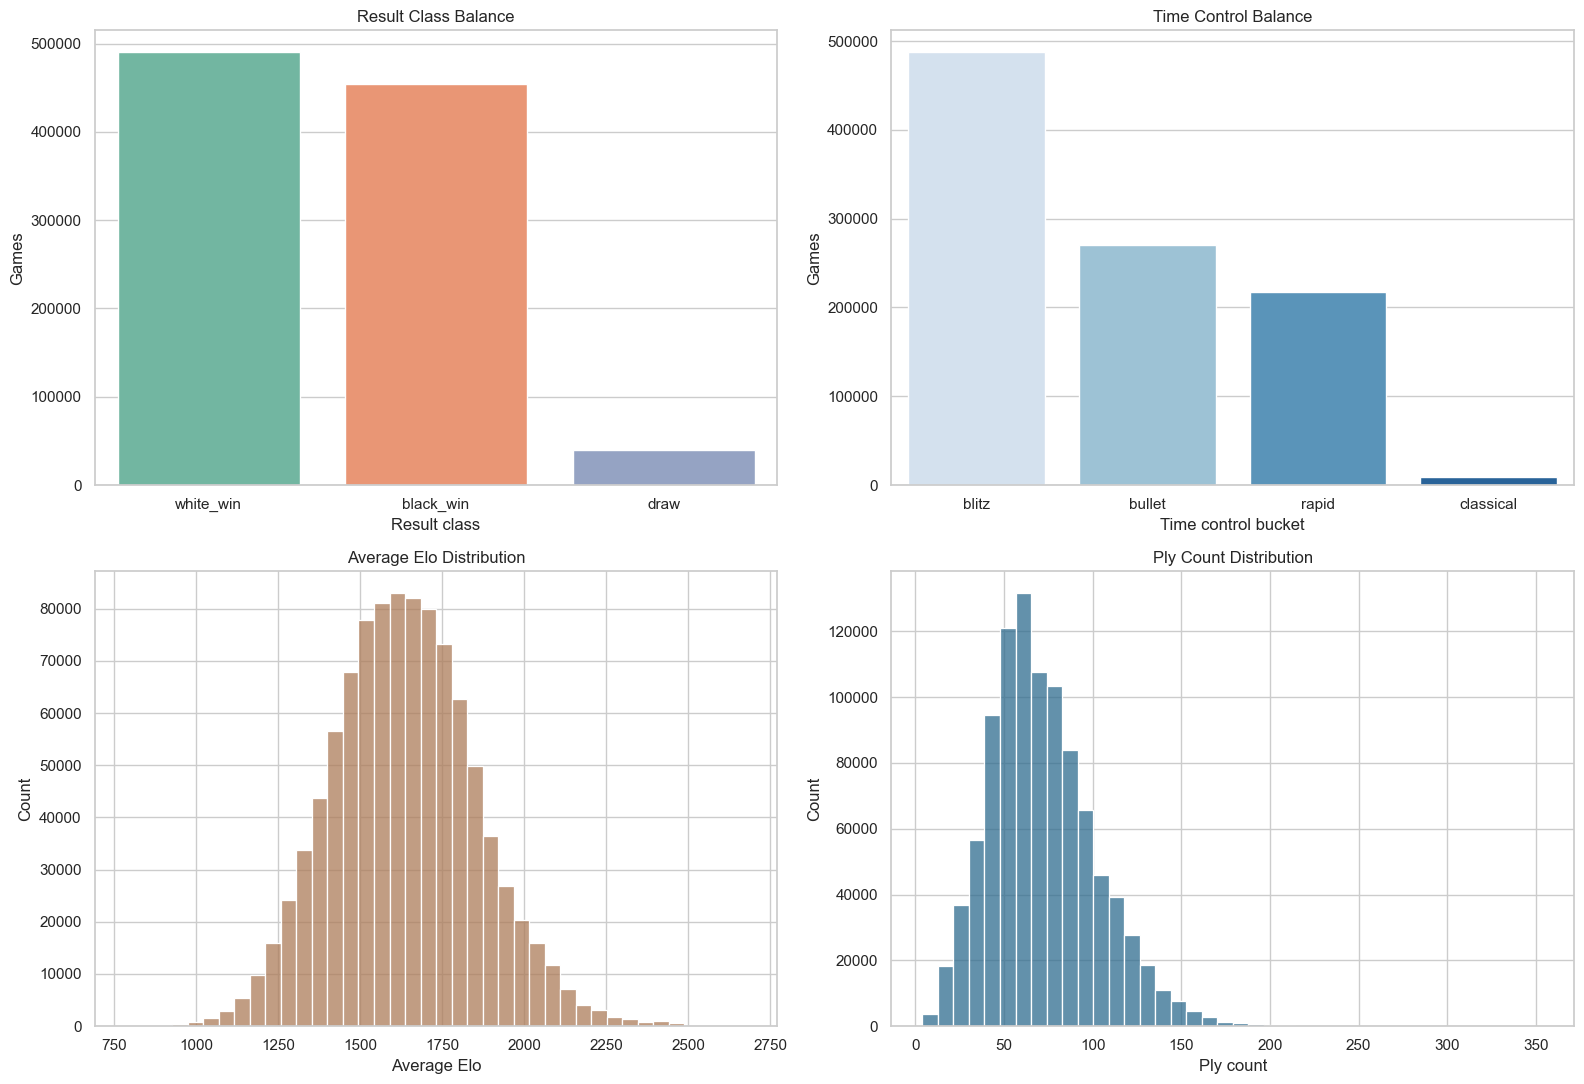

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(data=result_balance, x='result_class', y='count', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Result Class Balance')
axes[0, 0].set_xlabel('Result class')
axes[0, 0].set_ylabel('Games')

sns.barplot(data=time_control_balance, x='time_control_bucket', y='count', palette='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Time Control Balance')
axes[0, 1].set_xlabel('Time control bucket')
axes[0, 1].set_ylabel('Games')

sns.histplot(df['AvgElo'].dropna(), bins=40, color='#ad7c59', ax=axes[1, 0])
axes[1, 0].set_title('Average Elo Distribution')
axes[1, 0].set_xlabel('Average Elo')
axes[1, 0].set_ylabel('Count')

sns.histplot(df['PlyCount'].dropna(), bins=40, color='#2f6c8f', ax=axes[1, 1])
axes[1, 1].set_title('Ply Count Distribution')
axes[1, 1].set_xlabel('Ply count')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'dataset_overview.png', dpi=200)
plt.show()


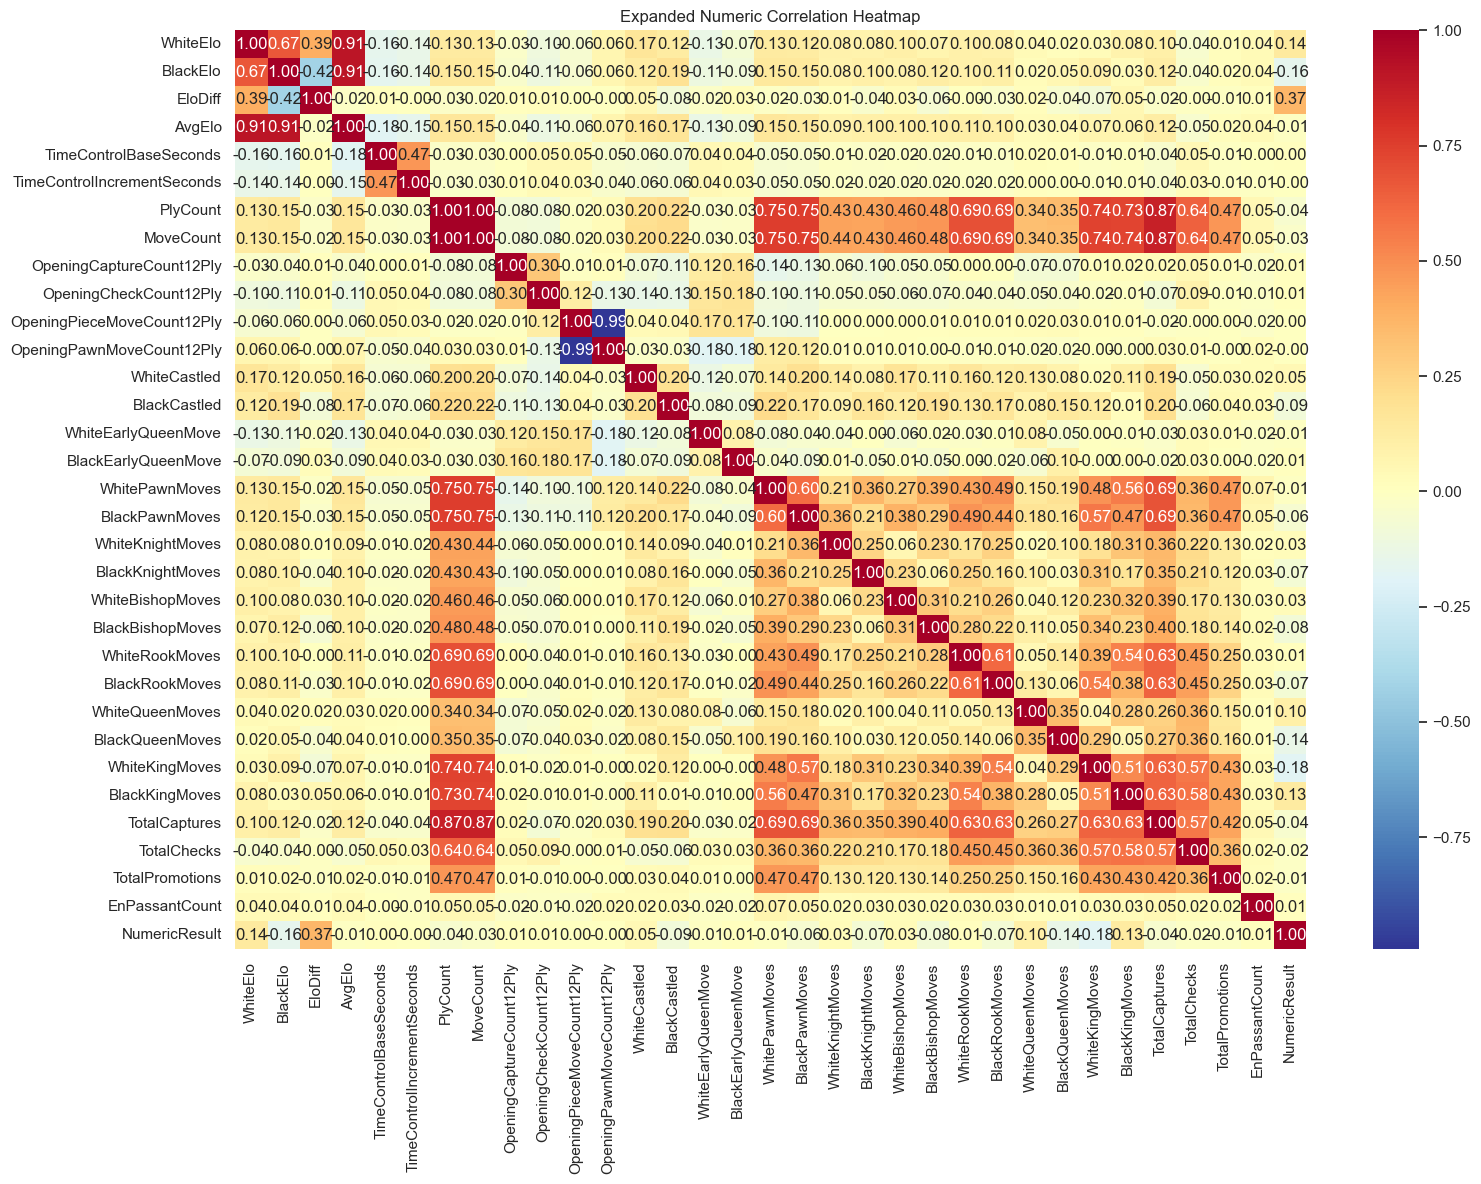

In [20]:
plot_cols = [
    'WhiteElo', 'BlackElo', 'EloDiff', 'AvgElo',
    'TimeControlBaseSeconds', 'TimeControlIncrementSeconds',
    'PlyCount', 'MoveCount',
    'OpeningCaptureCount12Ply', 'OpeningCheckCount12Ply',
    'OpeningPieceMoveCount12Ply', 'OpeningPawnMoveCount12Ply',
    'WhiteCastled', 'BlackCastled',
    'WhiteEarlyQueenMove', 'BlackEarlyQueenMove',
    'WhitePawnMoves', 'BlackPawnMoves',
    'WhiteKnightMoves', 'BlackKnightMoves',
    'WhiteBishopMoves', 'BlackBishopMoves',
    'WhiteRookMoves', 'BlackRookMoves',
    'WhiteQueenMoves', 'BlackQueenMoves',
    'WhiteKingMoves', 'BlackKingMoves',
    'TotalCaptures', 'TotalChecks', 'TotalPromotions', 'EnPassantCount',
    'NumericResult',
]
plot_cols = [c for c in plot_cols if c in df.columns]
corr_df = df[plot_cols].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, square=False)
plt.title('Expanded Numeric Correlation Heatmap')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'numeric_correlation_heatmap.png', dpi=200)
plt.show()


In [22]:
sample_n = min(RAW_SAMPLE_ROWS, len(df), EXCEL_ROW_LIMIT - 1)
raw_sample = df.sample(sample_n, random_state=RANDOM_STATE).sort_values('GameID').reset_index(drop=True)

clean_export_cols = [
    'GameID', 'Event', 'White', 'Black', 'Result', 'result_class', 'WhiteElo', 'BlackElo',
    'WhiteRatingDiff', 'BlackRatingDiff', 'EloDiff', 'AvgElo', 'UTCDate', 'UTCTime',
    'TimeControl', 'TimeControlBaseSeconds', 'TimeControlIncrementSeconds', 'TimeControlBucket',
    'Termination', 'ECO', 'Opening',
    'PlyCount', 'MoveCount', 'GameLengthBucket',
    'WhiteCastled', 'BlackCastled', 'WhiteCastleSide', 'BlackCastleSide',
    'WhiteEarlyQueenMove', 'BlackEarlyQueenMove',
    'OpeningCaptureCount12Ply', 'OpeningCheckCount12Ply',
    'WhitePawnMoves', 'BlackPawnMoves', 'WhiteKnightMoves', 'BlackKnightMoves',
    'WhiteBishopMoves', 'BlackBishopMoves', 'WhiteRookMoves', 'BlackRookMoves',
    'WhiteQueenMoves', 'BlackQueenMoves', 'WhiteKingMoves', 'BlackKingMoves',
    'TotalCaptures', 'TotalChecks', 'TotalPromotions', 'EnPassantCount',
]
clean_export_cols = [c for c in clean_export_cols if c in df.columns]
clean_df = df[clean_export_cols].copy()

clean_csv_path = OUTPUT_DIR / 'output_data_cleaned.csv'
excel_path = OUTPUT_DIR / 'output_data_summary.xlsx'

clean_df.to_csv(clean_csv_path, index=False)

excel_engine = None
for candidate in ['openpyxl', 'xlsxwriter']:
    try:
        __import__(candidate)
        excel_engine = candidate
        break
    except ModuleNotFoundError:
        pass

if excel_engine is not None:
    with pd.ExcelWriter(excel_path, engine=excel_engine) as writer:
        result_balance.to_excel(writer, sheet_name='result_balance', index=False)
        time_control_balance.to_excel(writer, sheet_name='time_control_balance', index=False)
        termination_balance.to_excel(writer, sheet_name='termination_balance', index=False)
        opening_family_balance.to_excel(writer, sheet_name='top_openings', index=False)
        column_summary.to_excel(writer, sheet_name='column_summary', index=False)
        numeric_summary.to_excel(writer, sheet_name='numeric_summary', index=False)
        raw_sample.to_excel(writer, sheet_name='raw_sample', index=False)
    print('Saved Excel workbook to:', excel_path)
    print('Excel engine used:', excel_engine)
else:
    result_balance.to_csv(OUTPUT_DIR / 'result_balance.csv', index=False)
    time_control_balance.to_csv(OUTPUT_DIR / 'time_control_balance.csv', index=False)
    termination_balance.to_csv(OUTPUT_DIR / 'termination_balance.csv', index=False)
    opening_family_balance.to_csv(OUTPUT_DIR / 'top_openings.csv', index=False)
    column_summary.to_csv(OUTPUT_DIR / 'column_summary.csv', index=False)
    numeric_summary.to_csv(OUTPUT_DIR / 'numeric_summary.csv', index=False)
    raw_sample.to_csv(OUTPUT_DIR / 'raw_sample.csv', index=False)
    print('No Excel engine installed. Wrote CSV fallback files instead.')

print('Saved cleaned CSV to:', clean_csv_path)
print('Raw sample rows prepared:', len(raw_sample))


No Excel engine installed. Wrote CSV fallback files instead.
Saved cleaned CSV to: /Users/phamhoanghai/Ureca/data_manipulation_output/output_data_cleaned.csv
Raw sample rows prepared: 200000


## Notes

- If `result_balance` shows a very small draw share, then the dataset is class-imbalanced for outcome modeling.
- If one `TimeControlBucket` dominates, stratified or grouped analysis by time control is a good idea.
- Excel export is summary-first on purpose, because full raw exports often exceed Excel's row limit and become slow to open.
